In [3]:
"""Hydrangea demo object test script.

This runs inside the notebook. Do not hardcode the notebook path.
The data mount is fixed at /storage/dandi_downloads.
"""

from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pynapple as nap

from hybrid_dynamics_core.base import HybridDynamicsAnalysis

DOWNLOAD_DIR = Path("/storage/dandi_downloads").resolve()
MODEL_DIR = DOWNLOAD_DIR / "hydrangea_models"
DANDISET_ID = "001695"
VERSION_ID = "0.260319.2023"
SUBJECTS = ["sub-M01", "sub-M02", "sub-M03", "sub-M05"]

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def print_session_table(download_root: Path):
    rows = []
    for subject_dir in sorted(download_root.glob("sub-*")):
        for nwb_file in sorted(subject_dir.rglob("*.nwb")):
            rel = nwb_file.relative_to(download_root)
            parts = rel.parts
            if len(parts) >= 3:
                subject = parts[0]
                session = parts[1] if len(parts) > 1 else "unknown"
                date = parts[-2] if len(parts) > 2 else "unknown"
            else:
                subject = subject_dir.name
                session = "unknown"
                date = "unknown"
            rows.append((subject, session, date, str(nwb_file)))

    if not rows:
        print(f"No NWB files found under {download_root}")
        return

    print("\nDANDI session inventory")
    print("-" * 110)
    print(f"{'subject':<12} {'session':<20} {'date':<20} {'nwb_file':<80}")
    print("-" * 110)
    for subject, session, date, path in rows:
        print(f"{subject:<12} {session:<20} {date:<20} {path:<80}")
    print("-" * 110)
    


def compute_running_speed(position_xy, smooth_window_s=0.25):
    """Compute speed from x/y position samples.

    This is intentionally external to the core object so behavior features can
    be user-specified per dataset.
    """
    t = position_xy.index.values
    x = position_xy["x"].values
    y = position_xy["y"].values

    dt = np.diff(t)
    dxy = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
    speed = np.zeros_like(t, dtype=float)
    speed[1:] = dxy / np.maximum(dt, 1e-12)

    if len(dt) > 0:
        smooth_n = max(1, int(smooth_window_s / np.median(dt)))
        speed = np.convolve(speed, np.ones(smooth_n) / smooth_n, mode="same")
    return t, speed


def plot_region_celltype_inventory(spike_group, region_key="cell_area", cell_type_key="cell_type"):
    regions = np.asarray(spike_group.get_info(region_key))
    cell_types = np.asarray(spike_group.get_info(cell_type_key))

    tab = pd.crosstab(
        pd.Series(regions, name="area"),
        pd.Series(cell_types, name="type"),
    )
    tab.insert(0, "Total", tab.sum(axis=1))
    print("\nCounts (region x cell_type, with Total):")
    print(tab)

    areas = tab.index.tolist()
    cols = tab.columns.tolist()
    n_bars = len(cols)
    x = np.arange(len(areas), dtype=float)
    width = 0.8 / n_bars
    cmap = plt.get_cmap("tab10")

    fig, ax = plt.subplots(figsize=(1.8 * len(areas) + 3, 5))
    for i, col in enumerate(cols):
        offsets = x + (i - (n_bars - 1) / 2) * width
        bars = ax.bar(offsets, tab[col].values, width, label=col, color=cmap(i % 10))
        ax.bar_label(bars, padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(areas)
    ax.set(xlabel="brain region", ylabel="unit count", title="Unit counts by region (Total + per cell type)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    return tab


def plot_raster_with_behavior(
    spike_group,
    behavior_signals,
    region_key="cell_area",
    cell_type_key="cell_type",
    n_units_per_group=5,
    window_s=60,
):
    unit_regions = np.asarray(spike_group.get_info(region_key))
    unit_types = np.asarray(spike_group.get_info(cell_type_key))
    unit_ids = np.asarray(spike_group.index)

    type_names = sorted(set(unit_types))
    type_colors = {ct: c for ct, c in zip(type_names, plt.get_cmap("tab10").colors)}

    selected = []
    for region in sorted(set(unit_regions)):
        for cell_type in type_names:
            matches = unit_ids[(unit_regions == region) & (unit_types == cell_type)]
            for uid in matches[:n_units_per_group]:
                selected.append((uid, region, cell_type))

    first_signal = next(iter(behavior_signals.values()))
    t_ref = np.asarray(first_signal["time"], dtype=float)
    window_start = float(t_ref[0])
    window_end = float(window_start + window_s)

    n_behavior = len(behavior_signals)
    fig, axes = plt.subplots(
        n_behavior + 1,
        1,
        figsize=(15, 3 + 2 * n_behavior),
        sharex=True,
        gridspec_kw={"height_ratios": [max(len(selected) / 8, 1.2)] + [1] * n_behavior},
    )

    raster_ax = axes[0]
    for row, (uid, region, cell_type) in enumerate(selected):
        spikes_win = spike_group[uid].get(window_start, window_end)
        raster_ax.plot(
            spikes_win.index.values,
            np.full(len(spikes_win), row),
            "|",
            color=type_colors[cell_type],
            markersize=4,
            mew=0.6,
        )
    raster_ax.set_yticks(range(len(selected)))
    raster_ax.set_yticklabels([f"{r[:4]}·{c[:4]}" for _, r, c in selected], fontsize=6)
    raster_ax.set(
        ylabel="unit (region·type)",
        title=f"Spike rasters — up to {n_units_per_group} units per cell type per region ({window_s}s window)",
    )
    raster_ax.invert_yaxis()
    raster_ax.legend(
        handles=[Line2D([0], [0], color=type_colors[ct], lw=2, label=ct) for ct in type_names],
        fontsize=8,
        loc="upper right",
        ncol=max(1, len(type_names)),
    )

    for i, (name, spec) in enumerate(behavior_signals.items(), start=1):
        t = np.asarray(spec["time"], dtype=float)
        y = np.asarray(spec["values"], dtype=float)
        color = spec.get("color", "k")
        axes[i].plot(t, y, lw=0.7, color=color)
        axes[i].set_ylabel(spec.get("ylabel", name))
        axes[i].grid(alpha=0.2)

    axes[-1].set_xlabel("time (s)")
    axes[0].set_xlim(window_start, window_end)
    plt.tight_layout()
    plt.show()
    
    

print_session_table(DOWNLOAD_DIR)




DANDI session inventory
--------------------------------------------------------------------------------------------------------------
subject      session              date                 nwb_file                                                                        
--------------------------------------------------------------------------------------------------------------
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb        
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240312T100000_behavior+ecephys.nwb
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
sub-M01      unknown              unknown              /storage/dandi_downloads/sub-M01/sub-M01_ses-20240314T100000_behavior+ecephys.nwb
sub-M01      unknown              unknown              /storage/dandi_

In [4]:

# Build the same session context used in the notebook.
# Hardcoded for the known dataset in this tutorial script.
session_nwb_path = Path(
    "/storage/dandi_downloads/sub-M01/"
    "sub-M01_ses-20240313T100000_behavior+ecephys.nwb"
).resolve()
session_nwb = nap.load_file(str(session_nwb_path))

spike_group = session_nwb["units"]
position_xy = session_nwb["Position"]

maze_start = float(position_xy.index[0])
maze_end = float(position_xy.index[-1])
maze_ep = nap.IntervalSet(start=maze_start, end=maze_end)
spike_group_maze = spike_group.restrict(maze_ep)

print("Session NWB path:", session_nwb_path)
print("Units before/after maze restriction:", len(spike_group), "/", len(spike_group_maze))


Session NWB path: /storage/dandi_downloads/sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
Units before/after maze restriction: 240 / 240



Counts (region x cell_type, with Total):
type  Total  Narrow Interneuron  Pyramidal Cell  Wide Interneuron
area                                                             
CA1     103                  15              85                 3
CA3      83                  55              27                 1
RSC      54                  23              15                16


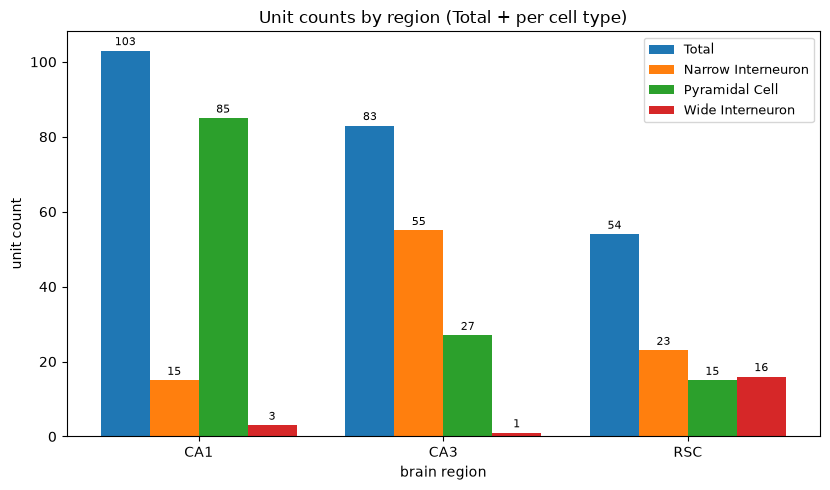

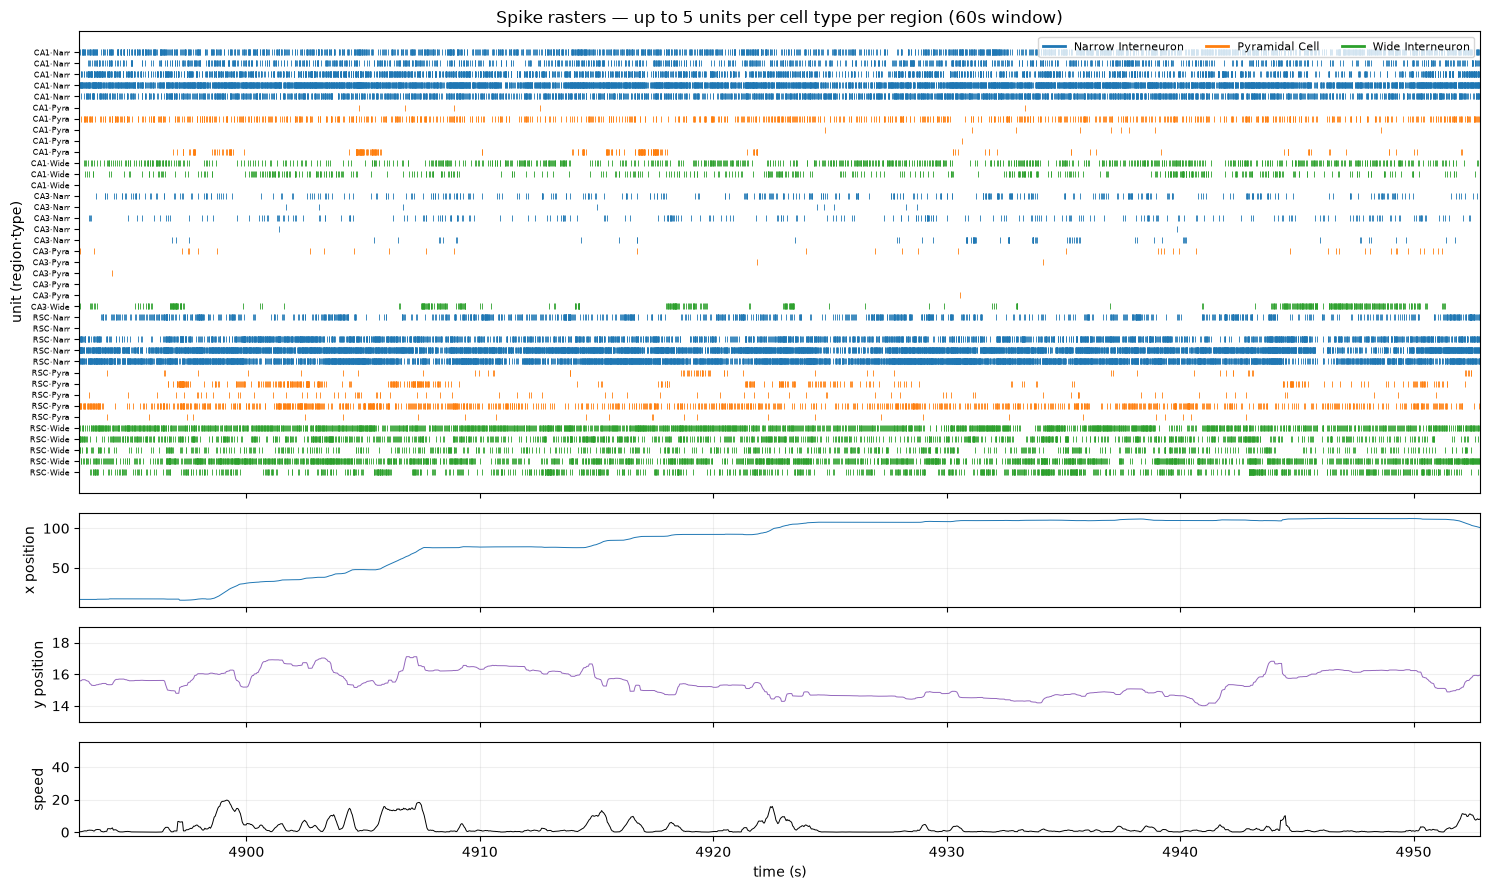

In [5]:

# 0) EDA before modeling: unit inventory and signal context
plot_region_celltype_inventory(spike_group_maze, region_key="cell_area", cell_type_key="cell_type")

speed_t, speed_vals = compute_running_speed(position_xy)
behavior_signals = {
    "x_position": {
        "time": position_xy.index.values,
        "values": position_xy["x"].values,
        "ylabel": "x position",
        "color": "tab:blue",
    },
    "y_position": {
        "time": position_xy.index.values,
        "values": position_xy["y"].values,
        "ylabel": "y position",
        "color": "tab:purple",
    },
    "running_speed": {
        "time": speed_t,
        "values": speed_vals,
        "ylabel": "speed",
        "color": "k",
    },
}
plot_raster_with_behavior(
    spike_group_maze,
    behavior_signals=behavior_signals,
    region_key="cell_area",
    cell_type_key="cell_type",
    n_units_per_group=5,
    window_s=60,
)

# Example usage: create a Hydrangea object and call steps in order.
hybdyn = HybridDynamicsAnalysis(
    spike_group=spike_group_maze,
    bin_size_s=0.050,
    maze_epoch=maze_ep,
    session_id="sub-M01_ses-20240313T100000",
    mouse_id="M01",
    embedding_method="pca",
    state_discovery_method="gaussian_hmm",
    random_state=0,
    report="selected",
)


/notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo/hybrid_dynamics_core/normalization.py:82: UserWarning: Dropped 3 neurons with no spikes in analyzed time interval. Per-region dropped counts -> CA1:1, CA3:2.
  warnings.warn(msg)


(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'Raw binned counts density (centered)'}, xlabel='count - mean(count)', ylabel='density'>,
         <Axes: title={'center': 'Z-scored values density (centered)'}, xlabel='z - mean(z)', ylabel='density'>,
         <Axes: title={'center': 'Mean vs var — raw'}, xlabel='mean', ylabel='var'>],
        [<Axes: title={'center': 'log10 firing rate density'}, xlabel='log10 firing rate (Hz)', ylabel='density'>,
         <Axes: title={'center': 'log10 firing rate density by cell_area'}, xlabel='log10 firing rate (Hz)', ylabel='density'>,
         <Axes: title={'center': 'Unit counts by region'}, xlabel='brain region', ylabel='unit count'>]],
       dtype=object))

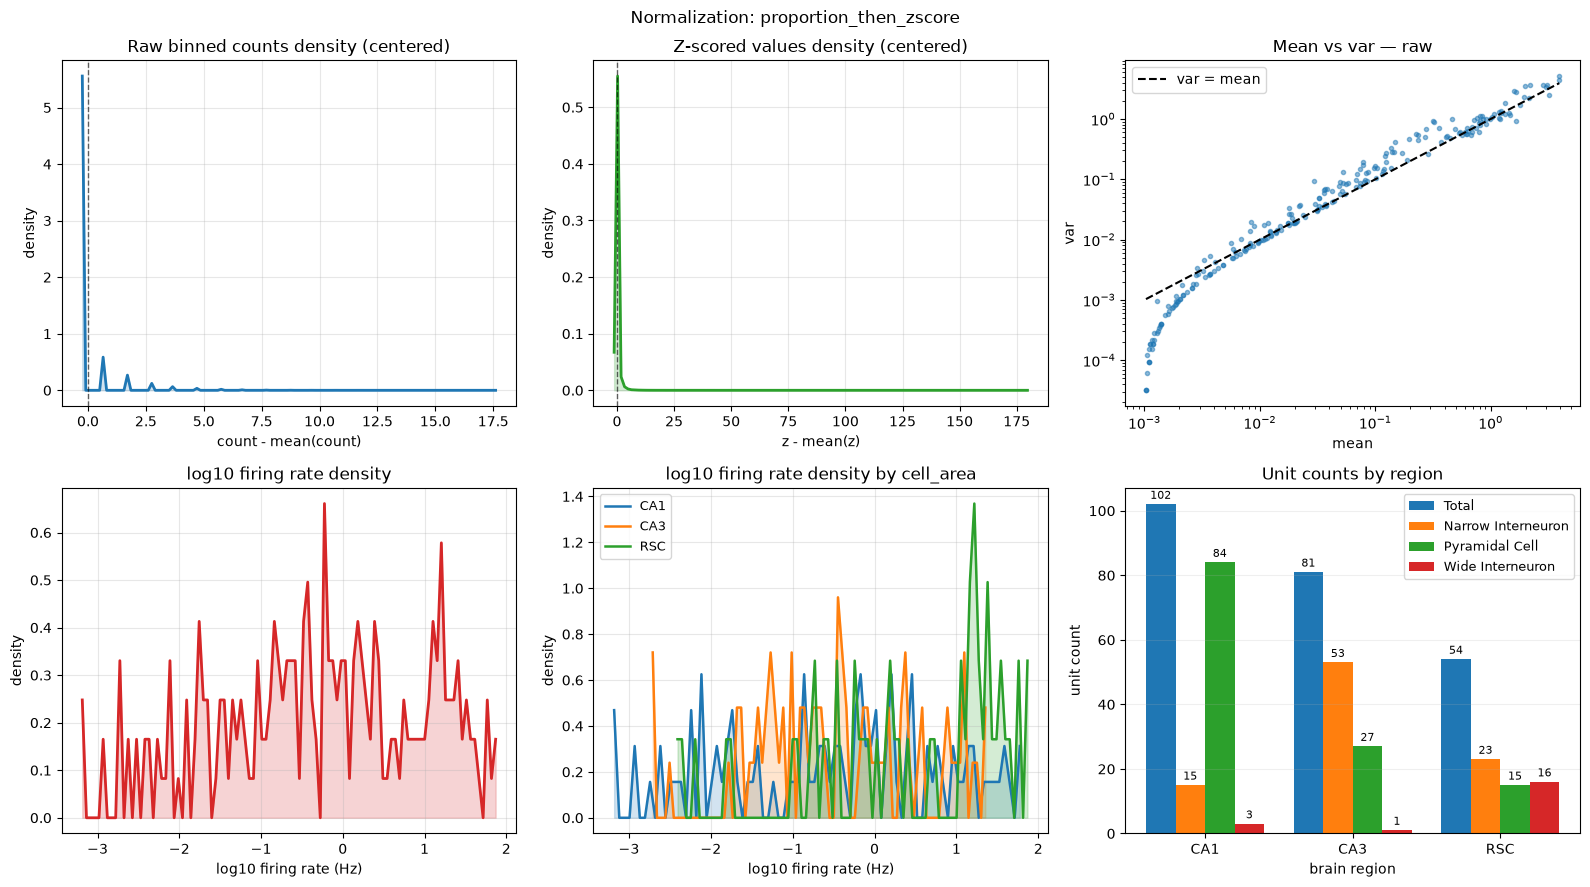

In [6]:

# 1) normalize
hybdyn.normalize(method="proportion_zscore", zscore=True, restrict_to_epoch=True)

# 1b) normalization-choice diagnostics
hybdyn.normalization_report(show=False)


In [ ]:

# 2) global embedding (PCA for now)
hybdyn.global_embedding(method="pca", n_components=10, whiten=False, standardize=True)
hybdyn.report_embeddings(show=False)

# 3) build folds
hybdyn.build_folds(
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    seed=0,
)

# 4) fit state-discovery model (locked method: gaussian_hmm)
hybdyn.fit_states(
    n_states_min=2,
    n_states_max=10,
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    n_iter=100,
    covariance_type="diag",
    verbose=False,
    use_cv=True,
    report="selected",
)

# Optional next step: local embedding inside one discovered state.
# hybdyn.local_embedding(state_labels=hybdyn.state_labels_, state_value=0, method="pca", label="state_0")
# hybdyn.report_embeddings(scope="local", label="state_0", show=False)

# 5) reporting
hybdyn.hmm_report(report="selected")
# hybdyn.hmm_report(report="full")
# hybdyn.hmm_report(report="none")

# 6) save and reload the selected model
saved_model_path = MODEL_DIR / f"{session_nwb_path.stem}_best_hmm.pkl"
hybdyn.save_hmm_model(saved_model_path)
reloaded_artifact = hybdyn.load_hmm_model(saved_model_path)

print("Saved model path:", saved_model_path)
print("Reloaded model states:", reloaded_artifact["n_states"])

print("Notebook working directory:", ROOT)
print("Download dir:", DOWNLOAD_DIR)
print("Best K:", hybdyn.best_k)
print("Model count:", len(hybdyn.hmm_models))

# 7) object summary for workflow tracking
hybdyn.describe(as_text=True)

